## Phase 1: Big Data Environment Setup & Data Acquisition

In [23]:
import os

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [24]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("Read Combined Arabic Dataset") \
    .master("local[*]") \
    .getOrCreate()

In [25]:
file_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/raw/processed-arabic-generated-abstrcts.csv"

df = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

In [26]:
df.printSchema()

root
 |-- label: string (nullable = true)
 |-- text: string (nullable = true)



In [27]:
df.show(5, truncate=100)

+-----+----------------------------------------------------------------------------------------------------+
|label|                                                                                                text|
+-----+----------------------------------------------------------------------------------------------------+
|human|كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات والبرامج وغيرها بدرا...|
|human|يعد العامل الثقافي احد ابرز الاسباب التي يعزى لها سقوط الدولة الموحدية ، حتى أنه لايقل من حيث الت...|
|human|شكلت تلك الجهود والمساعي الرائدة التي قام بها قادة الثورة خلال مرحلتها الأولى (1954-1956) للبحث ع...|
|human|يقوم المقال على اشكالية الضرائب الغير شرعية في مختلف مراحل دولتي المرابطين والموحدين أي منذ القيا...|
|human|تتفق المصادر التاريخية المتوفرة حول موضوع تطور الحركة الوطنية الجزائرية بعد نهاية الحرب العالمية ...|
+-----+----------------------------------------------------------------------------------------------------+
only showing top 5 

In [42]:
human_sample = df.filter(col("label") == "human").limit(2000)

ai_sample = df.filter(col("label") == "ai_generated").limit(2000)

small_df = human_sample.union(ai_sample)

small_df.groupBy("label").count().show()
print("Total rows:", small_df.count())

+------------+-----+
|       label|count|
+------------+-----+
|       human| 2000|
|ai_generated| 2000|
+------------+-----+

Total rows: 4000


In [43]:
small_df = small_df.dropna(subset=["text", "label"])

small_df.printSchema()
small_df.show(5, truncate=100)

small_df.groupBy("label").count().show()

root
 |-- label: string (nullable = true)
 |-- text: string (nullable = true)

+-----+----------------------------------------------------------------------------------------------------+
|label|                                                                                                text|
+-----+----------------------------------------------------------------------------------------------------+
|human|كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات والبرامج وغيرها بدرا...|
|human|يعد العامل الثقافي احد ابرز الاسباب التي يعزى لها سقوط الدولة الموحدية ، حتى أنه لايقل من حيث الت...|
|human|شكلت تلك الجهود والمساعي الرائدة التي قام بها قادة الثورة خلال مرحلتها الأولى (1954-1956) للبحث ع...|
|human|يقوم المقال على اشكالية الضرائب الغير شرعية في مختلف مراحل دولتي المرابطين والموحدين أي منذ القيا...|
|human|تتفق المصادر التاريخية المتوفرة حول موضوع تطور الحركة الوطنية الجزائرية بعد نهاية الحرب العالمية ...|
+-----+------------------------------------------

### Task 1.4

In [44]:
small_df.printSchema()

root
 |-- label: string (nullable = true)
 |-- text: string (nullable = true)



In [45]:
small_df.show()

+-----+--------------------+
|label|                text|
+-----+--------------------+
|human|كثيرا ما ارتبطت ا...|
|human|يعد العامل الثقاف...|
|human|شكلت تلك الجهود و...|
|human|يقوم المقال على ا...|
|human|تتفق المصادر التا...|
|human|تعددت صور الحياة ...|
|human|تروم هذه المحاولة...|
|human|يعالج هذا المقال ...|
|human|يتناول هذا المقال...|
|human|نعالج في هذا المو...|
|human|تكن خلال العصور ا...|
|human|يعتبر علم التاريخ...|
|human|نذ البدايات الأول...|
|human|يعد التراث الحضار...|
|human|زلنا في حاجة ماسة...|
|human|تهدف هذه الدراسة ...|
|human|تهدف هذه الدراسة ...|
|human|يعد الأمير عبد ال...|
|human|ينصب هذا العمل حو...|
|human|عبت العناصر الأند...|
+-----+--------------------+
only showing top 20 rows


In [46]:
from pyspark.sql.functions import col, sum as spark_sum

null_counts = small_df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in small_df.columns
])

null_counts.show()

+-----+----+
|label|text|
+-----+----+
|    0|   0|
+-----+----+



In [47]:
small_df.groupBy("label").count().show()

+------------+-----+
|       label|count|
+------------+-----+
|       human| 2000|
|ai_generated| 2000|
+------------+-----+



In [49]:
duplicate_count = small_df.count() - small_df.dropDuplicates(["text"]).count()

print("Duplicate text rows:", duplicate_count)

Duplicate text rows: 0


## Phase 2: Distributed Data Preprocessing & Storage

### Task 2.1: Design and implement the Arabic-specific text preprocessing pipeline

In [50]:
from pyspark.sql.functions import col, regexp_replace, trim, udf
from pyspark.sql.types import ArrayType, StringType
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

In [51]:
df = spark.read.parquet(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/small_dataset_parquet"
)

In [52]:
# Normalize directly on the same "text" column
df = df.withColumn(
    "text",
    regexp_replace(col("text"), "[\u064B-\u065F\u0670]", "")  # remove diacritics
)

df = df.withColumn(
    "text",
    regexp_replace(col("text"), "\u0640", "")  # remove tatweel
)

df = df.withColumn(
    "text",
    regexp_replace(col("text"), "[إأآٱ]", "ا")  # normalize Alif
)

df = df.withColumn(
    "text",
    regexp_replace(col("text"), "ى", "ي")  # normalize Alif Maqsura
)

df = df.withColumn(
    "text",
    regexp_replace(col("text"), "ة", "ه")  # normalize Ta Marbuta
)

df = df.withColumn(
    "text",
    regexp_replace(col("text"), "[^ء-ي\\s]", " ")  # keep Arabic letters only
)

df = df.withColumn(
    "text",
    regexp_replace(col("text"), "\\s+", " ")  # remove extra spaces
)

df = df.withColumn(
    "text",
    trim(col("text"))
)

In [53]:
df.printSchema()
df.show(5, truncate=100)

root
 |-- label: string (nullable = true)
 |-- text: string (nullable = true)

+-----+----------------------------------------------------------------------------------------------------+
|label|                                                                                                text|
+-----+----------------------------------------------------------------------------------------------------+
|human|كثيرا ما ارتبطت المصادر التاريخيه في الاندلس خاصه منها كتب التراجم والفهرسات والبرامج وغيرها بدرا...|
|human|يعد العامل الثقافي احد ابرز الاسباب التي يعزي لها سقوط الدوله الموحديه حتي انه لايقل من حيث التاث...|
|human|شكلت تلك الجهود والمساعي الرائده التي قام بها قاده الثوره خلال مرحلتها الاولي للبحث عن مصادر لتمو...|
|human|يقوم المقال علي اشكاليه الضرائب الغير شرعيه في مختلف مراحل دولتي المرابطين والموحدين اي منذ القيا...|
|human|تتفق المصادر التاريخيه المتوفره حول موضوع تطور الحركه الوطنيه الجزائريه بعد نهايه الحرب العالميه ...|
+-----+------------------------------------------

## Task 2.2: parquet file

In [58]:
output_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/small_dataset_parquet"

small_df.write.mode("overwrite").parquet(output_path)

print("Saved processed dataset to:", output_path)

Saved processed dataset to: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/small_dataset_parquet


In [95]:
spark.stop()

## Task 2.3: Conduct Exploratory Data Analysis (EDA)

In [96]:
spark = SparkSession.builder \
    .appName("Arabic Big Data Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

In [97]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, size, explode, count, countDistinct, round
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, NGram
import matplotlib.pyplot as plt
from wordcloud import WordCloud


input_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/small_dataset_parquet"

df = spark.read.parquet(input_path)

df.printSchema()
df.show(5, truncate=100)

root
 |-- label: string (nullable = true)
 |-- text: string (nullable = true)

+-----+----------------------------------------------------------------------------------------------------+
|label|                                                                                                text|
+-----+----------------------------------------------------------------------------------------------------+
|human|كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات والبرامج وغيرها بدرا...|
|human|يعد العامل الثقافي احد ابرز الاسباب التي يعزى لها سقوط الدولة الموحدية ، حتى أنه لايقل من حيث الت...|
|human|شكلت تلك الجهود والمساعي الرائدة التي قام بها قادة الثورة خلال مرحلتها الأولى (1954-1956) للبحث ع...|
|human|يقوم المقال على اشكالية الضرائب الغير شرعية في مختلف مراحل دولتي المرابطين والموحدين أي منذ القيا...|
|human|تتفق المصادر التاريخية المتوفرة حول موضوع تطور الحركة الوطنية الجزائرية بعد نهاية الحرب العالمية ...|
+-----+------------------------------------------

In [98]:
tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern="\\s+"
)

df = tokenizer.transform(df)

In [99]:
arabic_stopwords = [
    "من", "في", "على", "عن", "الى", "إلى", "أن", "إن", "كان", "كانت",
    "هو", "هي", "هذا", "هذه", "ذلك", "تلك", "مع", "كما", "قد", "تم",
    "لا", "ما", "لم", "لن", "او", "أو", "أي", "كل", "بين", "بعد",
    "قبل", "عند", "اذا", "إذا", "هناك", "وقد", "حيث", "ثم", "به",
    "بها", "له", "لها", "ومن", "وفي", "وعلى", "والتي", "الذي",
    "التي", "الذين", "اللاتي", "ان", "او"
]

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens",
    stopWords=arabic_stopwords
)

df = remover.transform(df)

df.select("label", "filtered_tokens").show(5, truncate=100)

+-----+----------------------------------------------------------------------------------------------------+
|label|                                                                                     filtered_tokens|
+-----+----------------------------------------------------------------------------------------------------+
|human|[كثيرا, ارتبطت, المصادر, التاريخية, الأندلس, خاصة, منها, كتب, التراجم, والفهرسات, والبرامج, وغيره...|
|human|[يعد, العامل, الثقافي, احد, ابرز, الاسباب, يعزى, سقوط, الدولة, الموحدية, ،, حتى, أنه, لايقل, التأ...|
|human|[شكلت, الجهود, والمساعي, الرائدة, قام, قادة, الثورة, خلال, مرحلتها, الأولى, (1954-1956), للبحث, م...|
|human|[يقوم, المقال, اشكالية, الضرائب, الغير, شرعية, مختلف, مراحل, دولتي, المرابطين, والموحدين, منذ, ال...|
|human|[تتفق, المصادر, التاريخية, المتوفرة, حول, موضوع, تطور, الحركة, الوطنية, الجزائرية, نهاية, الحرب, ...|
+-----+----------------------------------------------------------------------------------------------------+
only showing top 5 

In [100]:
words_df = df.select(
    "label",
    explode(col("filtered_tokens")).alias("word")
)

words_df = words_df.filter(col("word") != "")

word_freq = words_df.groupBy("word").count().orderBy(col("count").desc())

word_freq.show(30, truncate=False)

+--------+-----+
|word    |count|
+--------+-----+
|الدراسة |3370 |
|خلال    |2653 |
|البحث   |2152 |
|و       |1797 |
|مما     |1185 |
|تهدف    |1028 |
|دراسة   |1023 |
|،       |981  |
|تحليل   |885  |
|الضوء   |795  |
|العربية |747  |
|الجزائر |715  |
|اللغة   |703  |
|بشكل    |664  |
|أهمية   |654  |
|الجزائري|646  |
|دور     |641  |
|يمكن    |585  |
|يتناول  |581  |
|يهدف    |577  |
|لدى     |566  |
|مثل     |564  |
|تحقيق   |554  |
|تأثير   |539  |
|التركيز |535  |
|ذلك،    |529  |
|تعتبر   |528  |
|بعض     |522  |
|استخدام |517  |
|بالإضافة|512  |
+--------+-----+
only showing top 30 rows


In [101]:
word_freq_by_label = words_df.groupBy("label", "word") \
    .count() \
    .orderBy("label", col("count").desc())

word_freq_by_label.show(50, truncate=False)

+------------+----------+-----+
|label       |word      |count|
+------------+----------+-----+
|ai_generated|الدراسة   |2149 |
|ai_generated|البحث     |1639 |
|ai_generated|خلال      |1610 |
|ai_generated|مما       |973  |
|ai_generated|دراسة     |800  |
|ai_generated|تحليل     |775  |
|ai_generated|تهدف      |738  |
|ai_generated|الضوء     |641  |
|ai_generated|يتناول    |534  |
|ai_generated|بشكل      |508  |
|ai_generated|التركيز   |499  |
|ai_generated|مثل       |481  |
|ai_generated|ذلك،      |479  |
|ai_generated|يهدف      |476  |
|ai_generated|أهمية     |467  |
|ai_generated|تأثير     |437  |
|ai_generated|دور       |434  |
|ai_generated|بالإضافة  |427  |
|ai_generated|اللغة     |418  |
|ai_generated|العربية   |418  |
|ai_generated|تعتبر     |391  |
|ai_generated|فهم       |388  |
|ai_generated|استخدام   |378  |
|ai_generated|يمكن      |352  |
|ai_generated|الجزائر   |346  |
|ai_generated|الجزائري  |330  |
|ai_generated|تعزيز     |325  |
|ai_generated|تحقيق     |305  |
|ai_gene

In [102]:
top_words_pd = word_freq.limit(300).toPandas()

word_freq_dict = dict(zip(top_words_pd["word"], top_words_pd["count"]))

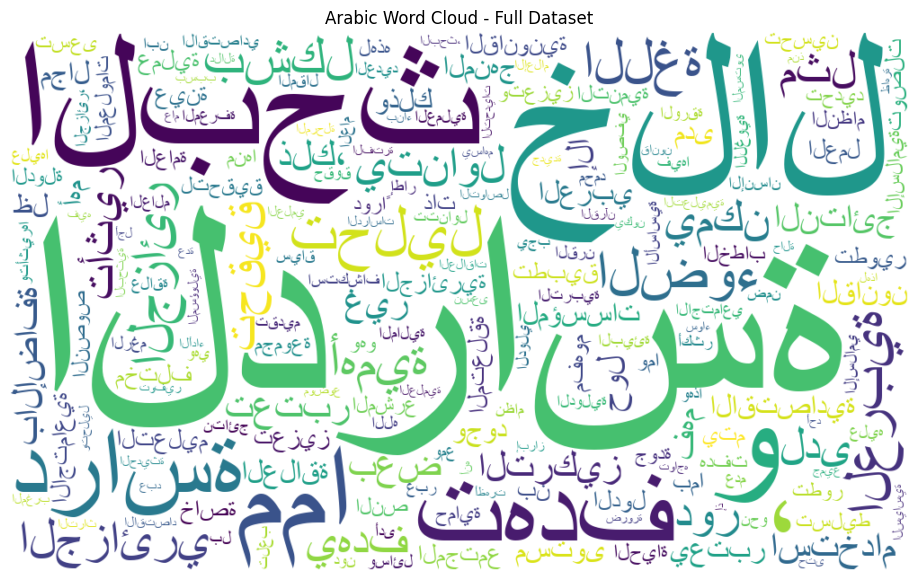

In [103]:
font_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project/src/font/ARIAL.TTF"
wordcloud = WordCloud(
    font_path=font_path,
    width=1000,
    height=600,
    background_color="white"
).generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Arabic Word Cloud - Full Dataset")
plt.show()

In [104]:
wordcloud.to_file(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/wordcloud_full_dataset.png"
)

In [105]:
bigram = NGram(
    n=2,
    inputCol="filtered_tokens",
    outputCol="bigrams"
)

bigram_df = bigram.transform(df)

bigram_freq = bigram_df.select(
    explode(col("bigrams")).alias("bigram")
).groupBy("bigram") \
 .count() \
 .orderBy(col("count").desc())

bigram_freq.show(30, truncate=False)

+------------------+-----+
|bigram            |count|
+------------------+-----+
|تهدف الدراسة      |790  |
|يتناول البحث      |491  |
|يهدف البحث        |445  |
|تسليط الضوء       |320  |
|توصلت الدراسة     |317  |
|خلال تحليل        |266  |
|الدراسة تحليل     |261  |
|اللغة العربية     |257  |
|هدفت الدراسة      |243  |
|البحث دراسة       |235  |
|خلال دراسة        |235  |
|المنهج الوصفي     |198  |
|تسعى الدراسة      |194  |
|بالإضافة ذلك،     |190  |
|ومع ذلك،          |183  |
|المشرع الجزائري   |171  |
|تتناول الدراسة    |170  |
|دوراً محورياً     |169  |
|الورقة البحثية    |156  |
|الدراسة استكشاف   |144  |
|ذات دلالة         |143  |
|خلال الفترة       |136  |
|أظهرت النتائج     |135  |
|دلالة إحصائية     |131  |
|الدراسة تسليط     |125  |
|مما أدى           |121  |
|الكلمات المفتاحية:|106  |
|الضوء أهمية       |102  |
|الصغيرة والمتوسطة |100  |
|وجود علاقة        |99   |
+------------------+-----+
only showing top 30 rows


In [106]:
total_tokens = words_df.count()
unique_tokens = words_df.select("word").distinct().count()

ttr = unique_tokens / total_tokens

print("Total tokens:", total_tokens)
print("Unique tokens:", unique_tokens)
print("TTR:", ttr)

Total tokens: 360324
Unique tokens: 64227
TTR: 0.1782479102141406


## Phase 3: Scalable Feature Engineering & Batch Modeling

### Task 3.1: Traditional Features

In [107]:
import stanza
stanza.download("ar")

2026-05-15 15:20:36 INFO: Downloaded file to /Users/mo-alnajjar/Library/Caches/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloaded file to /Users/mo-alnajjar/Library/Caches/stanza/1.11.0/resources/resources.json
2026-05-15 15:20:36 INFO: Downloading default packages for language: ar (Arabic) ...
INFO:stanza:Downloading default packages for language: ar (Arabic) ...
2026-05-15 15:20:36 INFO: File exists: /Users/mo-alnajjar/Library/Caches/stanza/1.11.0/resources/ar/default.zip
INFO:stanza:File exists: /Users/mo-alnajjar/Library/Caches/stanza/1.11.0/resources/ar/default.zip
2026-05-15 15:20:38 INFO: Finished downloading models and saved to /Users/mo-alnajjar/Library/Caches/stanza/1.11.0/resources
INFO:stanza:Finished downloading models and saved to /Users/mo-alnajjar/Library/Caches/stanza/1.11.0/resources


[['zip', 'default.zip']]

In [108]:
from pyspark.sql.functions import col, udf, monotonically_increasing_id
from pyspark.sql.types import DoubleType, IntegerType, StructType, StructField
from collections import Counter
import math

In [109]:
def calculate_honore_r(text):
    """
    Calculate Honoré's R measure.
    
    R = 100 * log(N) / (1 - V1 / V)
    
    N  = total number of tokens
    V  = number of unique tokens
    V1 = number of words that appear only once
    """

    if text is None or text.strip() == "":
        return 0.0

    tokens = text.split()
    N = len(tokens)

    if N == 0:
        return 0.0

    word_counts = Counter(tokens)

    V = len(word_counts)
    V1 = sum(1 for word, count in word_counts.items() if count == 1)

    if V == 0 or V1 == V:
        return 0.0

    honore_r = (100 * math.log(N)) / (1 - (V1 / V))

    return float(honore_r)
honore_r_udf = udf(calculate_honore_r, DoubleType())

In [110]:
nlp = None

def get_stanza_pipeline():
    """
    Load Stanza Arabic pipeline once per Python worker.
    This avoids loading the model for every row.
    """

    global nlp

    if nlp is None:
        nlp = stanza.Pipeline(
            lang="ar",
            processors="tokenize,pos,ner",
            use_gpu=False,
            verbose=False
        )

    return nlp

In [111]:
feature_schema = StructType([
    StructField("honore_r", DoubleType(), True),
    StructField("noun_frequency", DoubleType(), True),
    StructField("genitive_count", IntegerType(), True),
    StructField("entity_density", DoubleType(), True)
])

def extract_all_features(text):
    """
    Extract Arabic linguistic features:
    - noun frequency
    - honore_r
    - genitive count
    - entity density
    """

    if text is None or text.strip() == "":
        return (0.0, 0.0, 0, 0.0)

    try:
        
        tokens = text.split()
        N = len(tokens)

        if N == 0:
            honore_r = 0.0
        else:
            word_counts = Counter(tokens)
            V = len(word_counts)
            V1 = sum(1 for word, count in word_counts.items() if count == 1)

            if V == 0 or V1 == V:
                honore_r = 0.0
            else:
                honore_r = (100 * math.log(N)) / (1 - (V1 / V))

        
        pipeline = get_stanza_pipeline()
        doc = pipeline(text)

        words = []
        pos_tags = []

        for sentence in doc.sentences:
            for word in sentence.words:
                words.append(word.text)
                pos_tags.append(word.upos)

        total_words = len(words)

        if total_words == 0:
            return (float(honore_r), 0.0, 0, 0.0)

        # Noun frequency
        noun_count = sum(
            1 for tag in pos_tags
            if tag in ["NOUN", "PROPN"]
        )
        noun_frequency = noun_count / total_words

        # Genitive count: adjacent NOUN/PROPN pairs
        genitive_count = 0

        for i in range(len(pos_tags) - 1):
            if pos_tags[i] in ["NOUN", "PROPN"] and pos_tags[i + 1] in ["NOUN", "PROPN"]:
                genitive_count += 1

        # Entity density
        entity_count = len(doc.ents)
        entity_density = entity_count / total_words

        return (
            float(honore_r),
            float(noun_frequency),
            int(genitive_count),
            float(entity_density)
        )

    except Exception:
        return (0.0, 0.0, 0, 0.0)


features_udf = udf(extract_all_features, feature_schema)

In [112]:
df = df.withColumn(
    "features_struct",
    features_udf(col("text"))
)

df = df.select(
    "text",
    "label",
    col("features_struct.honore_r").alias("honore_r"),
    col("features_struct.noun_frequency").alias("noun_frequency"),
    col("features_struct.genitive_count").alias("genitive_count"),
    col("features_struct.entity_density").alias("entity_density")
)

In [113]:
df.show()

+--------------------+-----+------------------+-------------------+--------------+--------------------+
|                text|label|          honore_r|     noun_frequency|genitive_count|      entity_density|
+--------------------+-----+------------------+-------------------+--------------+--------------------+
|كثيرا ما ارتبطت ا...|human|4779.1234931115305|0.33121019108280253|            11|0.050955414012738856|
|يعد العامل الثقاف...|human| 4275.681527608534| 0.2727272727272727|             9|0.030303030303030304|
|شكلت تلك الجهود و...|human|3144.1277899991765| 0.3620689655172414|            19| 0.05517241379310345|
|يقوم المقال على ا...|human| 3278.906618119265| 0.3262411347517731|            15|  0.0425531914893617|
|تتفق المصادر التا...|human| 5672.804988737238|0.36257309941520466|            17|0.029239766081871343|
|تعددت صور الحياة ...|human|  8239.55633125103|0.30718954248366015|            15|  0.0196078431372549|
|تروم هذه المحاولة...|human|10628.231668976145|0.365517241379310

/opt/homebrew/Cellar/python@3.14/3.14.5/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/resource_tracker.py:475: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-y63zv5rb'}
  warnings.warn(


### 

### Task Task 3.2: Advanced Features

In [114]:
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern="\\s+",
    minTokenLength=2
)

final_df = tokenizer.transform(df)

In [115]:
final_df.show()

+--------------------+-----+------------------+-------------------+--------------+--------------------+--------------------+
|                text|label|          honore_r|     noun_frequency|genitive_count|      entity_density|              tokens|
+--------------------+-----+------------------+-------------------+--------------+--------------------+--------------------+
|كثيرا ما ارتبطت ا...|human|4779.1234931115305|0.33121019108280253|            11|0.050955414012738856|[كثيرا, ما, ارتبط...|
|يعد العامل الثقاف...|human| 4275.681527608534| 0.2727272727272727|             9|0.030303030303030304|[يعد, العامل, الث...|
|شكلت تلك الجهود و...|human|3144.1277899991765| 0.3620689655172414|            19| 0.05517241379310345|[شكلت, تلك, الجهو...|
|يقوم المقال على ا...|human| 3278.906618119265| 0.3262411347517731|            15|  0.0425531914893617|[يقوم, المقال, عل...|
|تتفق المصادر التا...|human| 5672.804988737238|0.36257309941520466|            17|0.029239766081871343|[تتفق, المصادر, ا...|


/opt/homebrew/Cellar/python@3.14/3.14.5/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/resource_tracker.py:475: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-fxhpxfu9'}
  warnings.warn(


In [116]:
count_vectorizer = CountVectorizer(
    inputCol="tokens",
    outputCol="raw_tf_features",
    vocabSize=1000,
    minDF=2
)

cv_model = count_vectorizer.fit(final_df)
final_df = cv_model.transform(final_df)

In [117]:
idf = IDF(
    inputCol="raw_tf_features",
    outputCol="tfidf_features"
)

idf_model = idf.fit(final_df)
final_df = idf_model.transform(final_df)

In [118]:
final_df.select(
    "text",
    "label",
    "honore_r",
    "noun_frequency",
    "genitive_count",
    "entity_density",
    "tfidf_features"
).show(5, truncate=100)

+----------------------------------------------------------------------------------------------------+-----+------------------+-------------------+--------------+--------------------+----------------------------------------------------------------------------------------------------+
|                                                                                                text|label|          honore_r|     noun_frequency|genitive_count|      entity_density|                                                                                      tfidf_features|
+----------------------------------------------------------------------------------------------------+-----+------------------+-------------------+--------------+--------------------+----------------------------------------------------------------------------------------------------+
|كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات والبرامج وغيرها بدرا...|human|4779.1234931115305|0.3312101910828025

/opt/homebrew/Cellar/python@3.14/3.14.5/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/resource_tracker.py:475: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-76hjzz79'}
  warnings.warn(


In [119]:
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(
    inputCol="label",
    outputCol="label_index"
)

label_model = label_indexer.fit(final_df)
final_df = label_model.transform(final_df)

final_df.select("label", "label_index").show(10)

+-----+-----------+
|label|label_index|
+-----+-----------+
|human|        1.0|
|human|        1.0|
|human|        1.0|
|human|        1.0|
|human|        1.0|
|human|        1.0|
|human|        1.0|
|human|        1.0|
|human|        1.0|
|human|        1.0|
+-----+-----------+
only showing top 10 rows


In [120]:
print(label_model.labels)

['ai_generated', 'human']


In [121]:
train_df, val_df, test_df = final_df.randomSplit(
    [0.70, 0.15, 0.15],
    seed=42
)

In [122]:
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

In [123]:
train_df.count()
val_df.count()
test_df.count()

564

/opt/homebrew/Cellar/python@3.14/3.14.5/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/resource_tracker.py:475: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-wg6uo4_j'}
  warnings.warn(


In [124]:
base_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed"

train_df.write.mode("overwrite").parquet(f"{base_path}/train_small_ready_parquet")
val_df.write.mode("overwrite").parquet(f"{base_path}/val_small_ready_parquet")
test_df.write.mode("overwrite").parquet(f"{base_path}/test_small_ready_parquet")

In [125]:
train_df = spark.read.parquet(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/train_small_ready_parquet"
)

val_df = spark.read.parquet(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/val_small_ready_parquet"
)

test_df = spark.read.parquet(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/test_small_ready_parquet"
)

In [128]:
train_df.show(2)

+--------------------+-----+-----------------+------------------+--------------+--------------------+--------------------+--------------------+--------------------+-----------+
|                text|label|         honore_r|    noun_frequency|genitive_count|      entity_density|              tokens|     raw_tf_features|      tfidf_features|label_index|
+--------------------+-----+-----------------+------------------+--------------+--------------------+--------------------+--------------------+--------------------+-----------+
|.الاهتمام بالمخطو...|human|4400.495955499733|0.2847222222222222|             8|0.027777777777777776|[.الاهتمام, بالمخ...|(1000,[0,4,5,7,11...|(1000,[0,4,5,7,11...|        1.0|
|.ملخص الدراسة. في...|human|4443.167466102949|0.3876651982378855|            28|0.004405286343612335|[.ملخص, الدراسة.,...|(1000,[0,1,2,3,6,...|(1000,[0,1,2,3,6,...|        1.0|
+--------------------+-----+-----------------+------------------+--------------+--------------------+--------------

### Task 3.4: Baseline Model

In [129]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql.functions import col

In [130]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "honore_r",
        "noun_frequency",
        "genitive_count",
        "entity_density"
    ],
    outputCol="features"
)

train_df = assembler.transform(train_df)
val_df = assembler.transform(val_df)
test_df = assembler.transform(test_df)

In [131]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label_index",
    maxIter=5,
    regParam=0.1,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_df)

In [132]:
val_predictions = lr_model.transform(val_df)

val_predictions.select(
    "label",
    "label_index",
    "prediction",
    "probability"
).show(10, truncate=100)

+------------+-----------+----------+----------------------------------------+
|       label|label_index|prediction|                             probability|
+------------+-----------+----------+----------------------------------------+
|       human|        1.0|       1.0|[0.17308517996200995,0.8269148200379901]|
|ai_generated|        0.0|       1.0|[0.42349638536127665,0.5765036146387233]|
|       human|        1.0|       1.0|[0.40895213783141426,0.5910478621685857]|
|       human|        1.0|       0.0| [0.7199270625348253,0.2800729374651747]|
|       human|        1.0|       1.0|[0.24930818050711953,0.7506918194928804]|
|       human|        1.0|       1.0| [0.3733026592050731,0.6266973407949269]|
|       human|        1.0|       1.0|[0.46761758970870937,0.5323824102912906]|
|       human|        1.0|       0.0| [0.5203689286916986,0.4796310713083014]|
|       human|        1.0|       1.0| [0.1647445674279776,0.8352554325720224]|
|       human|        1.0|       0.0|[0.501704502792

In [133]:
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="accuracy"
)

val_accuracy = accuracy_evaluator.evaluate(val_predictions)

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.6964912280701754


In [134]:
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="f1"
)

val_f1 = f1_evaluator.evaluate(val_predictions)

print("Validation F1-score:", val_f1)

Validation F1-score: 0.6963557643628115


In [135]:
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

val_precision = precision_evaluator.evaluate(val_predictions)

print("Validation Precision:", val_precision)

Validation Precision: 0.6998379486325778


In [136]:
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="weightedRecall"
)

val_recall = recall_evaluator.evaluate(val_predictions)

print("Validation Recall:", val_recall)

Validation Recall: 0.6964912280701754


In [137]:
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label_index",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

val_auc = auc_evaluator.evaluate(val_predictions)

print("Validation ROC-AUC:", val_auc)

Validation ROC-AUC: 0.776322442989109


In [138]:
val_predictions.groupBy("label_index", "prediction").count().show()

+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       1.0|  101|
|        1.0|       1.0|  201|
|        1.0|       0.0|   72|
|        0.0|       0.0|  196|
+-----------+----------+-----+



In [139]:
confusion_matrix = val_predictions.groupBy("label_index", "prediction") \
    .count() \
    .orderBy("label_index", "prediction")

confusion_matrix.show()

+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  196|
|        0.0|       1.0|  101|
|        1.0|       0.0|   72|
|        1.0|       1.0|  201|
+-----------+----------+-----+



In [140]:
test_predictions = lr_model.transform(test_df)

In [141]:
test_accuracy = accuracy_evaluator.evaluate(test_predictions)
test_f1 = f1_evaluator.evaluate(test_predictions)
test_precision = precision_evaluator.evaluate(test_predictions)
test_recall = recall_evaluator.evaluate(test_predictions)
test_auc = auc_evaluator.evaluate(test_predictions)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)
print("Test ROC-AUC:", test_auc)

Test Accuracy: 0.675531914893617
Test Precision: 0.676873830698552
Test Recall: 0.675531914893617
Test F1-score: 0.6754350042413253
Test ROC-AUC: 0.7560113243158239


In [142]:
test_predictions.groupBy("label_index", "prediction") \
    .count() \
    .orderBy("label_index", "prediction") \
    .show()

+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  193|
|        0.0|       1.0|   82|
|        1.0|       0.0|  101|
|        1.0|       1.0|  188|
+-----------+----------+-----+



### Task 3.5: Advanced ML Models

In [143]:
train_df.select("features", "label_index").show(5, truncate=50)

train_df.groupBy("label", "label_index").count().show()

+--------------------------------------------------+-----------+
|                                          features|label_index|
+--------------------------------------------------+-----------+
|[4400.495955499733,0.2847222222222222,8.0,0.027...|        1.0|
|[4443.167466102949,0.3876651982378855,28.0,0.00...|        1.0|
|[2492.0940468238146,0.3804878048780488,30.0,0.0...|        0.0|
|[2815.3263961621956,0.2857142857142857,6.0,0.04...|        1.0|
|[2831.915419792959,0.3902439024390244,13.0,0.01...|        1.0|
+--------------------------------------------------+-----------+
only showing top 5 rows
+------------+-----------+-----+
|       label|label_index|count|
+------------+-----------+-----+
|ai_generated|        0.0| 1428|
|       human|        1.0| 1438|
+------------+-----------+-----+



In [144]:
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

train_df.count()
val_df.count()
test_df.count()

564

In [148]:
def evaluate_model(predictions, model_name, dataset_name):
    accuracy = accuracy_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)
    auc = auc_evaluator.evaluate(predictions)

    print(f"===== {model_name} - {dataset_name} Results =====")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("ROC-AUC:", auc)

    print("Confusion Matrix:")
    predictions.groupBy("label_index", "prediction") \
        .count() \
        .orderBy("label_index", "prediction") \
        .show()

    return {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc
    }

In [146]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC

In [147]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label_index",
    predictionCol="prediction",
    probabilityCol="probability",
    numTrees=20,
    maxDepth=5,
    seed=42
)

rf_model = rf.fit(train_df)

In [149]:
rf_val_predictions = rf_model.transform(val_df)

rf_val_results = evaluate_model(
    rf_val_predictions,
    "Random Forest",
    "Validation"
)

===== Random Forest - Validation Results =====
Accuracy: 0.7210526315789474
Precision: 0.7210140617532779
Recall: 0.7210526315789474
F1-score: 0.7210311261153426
ROC-AUC: 0.792503792503793
Confusion Matrix:
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  218|
|        0.0|       1.0|   79|
|        1.0|       0.0|   80|
|        1.0|       1.0|  193|
+-----------+----------+-----+



In [150]:
rf_test_predictions = rf_model.transform(test_df)

rf_test_results = evaluate_model(
    rf_test_predictions,
    "Random Forest",
    "Test"
)

===== Random Forest - Test Results =====
Accuracy: 0.6879432624113475
Precision: 0.6899711648668764
Recall: 0.6879432624113475
F1-score: 0.6877077449299286
ROC-AUC: 0.7537967914438506
Confusion Matrix:
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  199|
|        0.0|       1.0|   76|
|        1.0|       0.0|  100|
|        1.0|       1.0|  189|
+-----------+----------+-----+



In [151]:
rf_model.write().overwrite().save(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/models/random_forest_model"
)

In [152]:
rf_results = []

for num_trees in [10, 20, 30]:
    for max_depth in [3, 5]:
        rf = RandomForestClassifier(
            featuresCol="features",
            labelCol="label_index",
            predictionCol="prediction",
            probabilityCol="probability",
            numTrees=num_trees,
            maxDepth=max_depth,
            seed=42
        )

        model = rf.fit(train_df)
        predictions = model.transform(val_df)

        f1 = f1_evaluator.evaluate(predictions)
        accuracy = accuracy_evaluator.evaluate(predictions)

        rf_results.append((num_trees, max_depth, accuracy, f1))

        print(
            "numTrees:", num_trees,
            "maxDepth:", max_depth,
            "Accuracy:", accuracy,
            "F1:", f1
        )

numTrees: 10 maxDepth: 3 Accuracy: 0.7052631578947368 F1: 0.7049536215749417
numTrees: 10 maxDepth: 5 Accuracy: 0.7087719298245614 F1: 0.7087252218089639
numTrees: 20 maxDepth: 3 Accuracy: 0.6877192982456141 F1: 0.6877616523553904
numTrees: 20 maxDepth: 5 Accuracy: 0.7210526315789474 F1: 0.7210311261153426
numTrees: 30 maxDepth: 3 Accuracy: 0.6929824561403509 F1: 0.6923203934891138
numTrees: 30 maxDepth: 5 Accuracy: 0.7280701754385965 F1: 0.7281229758816337


In [153]:
best_rf = sorted(rf_results, key=lambda x: x[3], reverse=True)[0]

print("Best Random Forest setting:")
print("numTrees:", best_rf[0])
print("maxDepth:", best_rf[1])
print("Accuracy:", best_rf[2])
print("F1:", best_rf[3])

Best Random Forest setting:
numTrees: 30
maxDepth: 5
Accuracy: 0.7280701754385965
F1: 0.7281229758816337


In [154]:
svm = LinearSVC(
    featuresCol="features",
    labelCol="label_index",
    predictionCol="prediction",
    rawPredictionCol="rawPrediction",
    maxIter=10,
    regParam=0.1
)

svm_model = svm.fit(train_df)

In [155]:
svm_val_predictions = svm_model.transform(val_df)

svm_val_results = evaluate_model(
    svm_val_predictions,
    "Linear SVM",
    "Validation"
)

===== Linear SVM - Validation Results =====
Accuracy: 0.7140350877192982
Precision: 0.7140800375865686
Recall: 0.7140350877192982
F1-score: 0.7140553644794969
ROC-AUC: 0.7784314450981115
Confusion Matrix:
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  215|
|        0.0|       1.0|   82|
|        1.0|       0.0|   81|
|        1.0|       1.0|  192|
+-----------+----------+-----+



In [156]:
svm_test_predictions = svm_model.transform(test_df)

svm_test_results = evaluate_model(
    svm_test_predictions,
    "Linear SVM",
    "Test"
)

===== Linear SVM - Test Results =====
Accuracy: 0.6950354609929078
Precision: 0.6996527970550446
Recall: 0.6950354609929078
F1-score: 0.694159523541489
ROC-AUC: 0.7584020132117028
Confusion Matrix:
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  208|
|        0.0|       1.0|   67|
|        1.0|       0.0|  105|
|        1.0|       1.0|  184|
+-----------+----------+-----+



In [157]:
svm_model.write().overwrite().save(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/models/linear_svm_model"
)

In [158]:
svm_results = []

for reg_param in [0.01, 0.1, 0.5]:
    for max_iter in [5, 10]:
        svm = LinearSVC(
            featuresCol="features",
            labelCol="label_index",
            predictionCol="prediction",
            rawPredictionCol="rawPrediction",
            maxIter=max_iter,
            regParam=reg_param
        )

        model = svm.fit(train_df)
        predictions = model.transform(val_df)

        f1 = f1_evaluator.evaluate(predictions)
        accuracy = accuracy_evaluator.evaluate(predictions)

        svm_results.append((reg_param, max_iter, accuracy, f1))

        print(
            "regParam:", reg_param,
            "maxIter:", max_iter,
            "Accuracy:", accuracy,
            "F1:", f1
        )

regParam: 0.01 maxIter: 5 Accuracy: 0.7140350877192982 F1: 0.714153992048729
regParam: 0.01 maxIter: 10 Accuracy: 0.7140350877192982 F1: 0.7141539393356072
regParam: 0.1 maxIter: 5 Accuracy: 0.7140350877192982 F1: 0.714153992048729
regParam: 0.1 maxIter: 10 Accuracy: 0.7140350877192982 F1: 0.7140553644794969
regParam: 0.5 maxIter: 5 Accuracy: 0.6807017543859649 F1: 0.680745060273489
regParam: 0.5 maxIter: 10 Accuracy: 0.6929824561403509 F1: 0.6923203934891138


In [159]:
best_svm = sorted(svm_results, key=lambda x: x[3], reverse=True)[0]

print("Best Linear SVM setting:")
print("regParam:", best_svm[0])
print("maxIter:", best_svm[1])
print("Accuracy:", best_svm[2])
print("F1:", best_svm[3])

Best Linear SVM setting:
regParam: 0.01
maxIter: 5
Accuracy: 0.7140350877192982
F1: 0.714153992048729


In [160]:
import pandas as pd

results_df = pd.DataFrame([
    rf_val_results,
    rf_test_results,
    svm_val_results,
    svm_test_results
])

results_df

,model,dataset,accuracy,precision,recall,f1,roc_auc
0,Random Forest,Validation,0.721053,0.721014,0.721053,0.721031,0.792504
1,Random Forest,Test,0.687943,0.689971,0.687943,0.687708,0.753797
2,Linear SVM,Validation,0.714035,0.714080,0.714035,0.714055,0.778431
3,Linear SVM,Test,0.695035,0.699653,0.695035,0.694160,0.758402


In [259]:
models_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project/models"

cv_model.write().overwrite().save(
    f"{models_path}/count_vectorizer_model"
)

idf_model.write().overwrite().save(
    f"{models_path}/idf_model"
)

lr_model.write().overwrite().save(
    f"{models_path}/baseline_logistic_regression_model"
)

print("Models saved successfully.")

Models saved successfully.


## Phase 4: Stream Processing & Comprehensive Evaluation

### Task 4.1 & 4.2: Stream Simulation & Real Time Deployment

In [162]:
base_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project"

stream_input_path = f"{base_path}/data/stream_input"
stream_output_path = f"{base_path}/data/stream_output"
checkpoint_path = f"{base_path}/data/checkpoints/stream_simulation"

os.makedirs(stream_input_path, exist_ok=True)
os.makedirs(stream_output_path, exist_ok=True)
os.makedirs(checkpoint_path, exist_ok=True)

print("Stream folders created.")

Stream folders created.


In [163]:
df = spark.read.parquet(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/small_dataset_parquet"
)

In [164]:
stream_source_df = df.select("text", "label")

In [165]:
stream_pdf = stream_source_df.limit(100).toPandas()

batch_size = 10

for i in range(0, len(stream_pdf), batch_size):
    batch = stream_pdf.iloc[i:i + batch_size]
    batch_file = f"{stream_input_path}/batch_{i//batch_size}.csv"
    batch.to_csv(batch_file, index=False, encoding="utf-8-sig")
    print("Created:", batch_file)

Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_0.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_1.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_2.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_3.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_4.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_5.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_6.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_7.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_8.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_input/batch_9.csv


In [166]:
waiting_path = f"{base_path}/data/stream_waiting"

os.makedirs(waiting_path, exist_ok=True)

stream_pdf = stream_source_df.limit(100).toPandas()

for i in range(0, len(stream_pdf), batch_size):
    batch = stream_pdf.iloc[i:i + batch_size]
    batch_file = f"{waiting_path}/batch_{i//batch_size}.csv"
    batch.to_csv(batch_file, index=False, encoding="utf-8-sig")
    print("Prepared:", batch_file)

Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_0.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_1.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_2.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_3.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_4.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_5.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_6.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_7.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_8.csv
Prepared: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/stream_waiting/batch_9.csv


In [167]:
from pyspark.sql.types import StructType, StructField, StringType

stream_schema = StructType([
    StructField("text", StringType(), True),
    StructField("label", StringType(), True)
])

In [168]:
stream_df = spark.readStream \
    .schema(stream_schema) \
    .option("header", True) \
    .csv(stream_input_path)

In [169]:
stream_df.printSchema()

root
 |-- text: string (nullable = true)
 |-- label: string (nullable = true)



In [170]:
from pyspark.sql.functions import current_timestamp, length, col

processed_stream_df = stream_df.withColumn(
    "arrival_time",
    current_timestamp()
).withColumn(
    "text_length",
    length(col("text"))
)

In [171]:
query = processed_stream_df.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", False) \
    .option("checkpointLocation", checkpoint_path) \
    .start()

26/05/15 20:05:29 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [172]:
import shutil
import time

waiting_files = sorted([
    f for f in os.listdir(waiting_path)
    if f.endswith(".csv")
])

for file_name in waiting_files[:5]:
    source_file = os.path.join(waiting_path, file_name)
    target_file = os.path.join(stream_input_path, file_name)

    shutil.move(source_file, target_file)

    print("Moved to stream input:", file_name)
    time.sleep(5)

Moved to stream input: batch_0.csv
Moved to stream input: batch_1.csv
Moved to stream input: batch_2.csv
Moved to stream input: batch_3.csv
Moved to stream input: batch_4.csv


In [173]:
query.stop()

26/05/15 20:06:29 WARN DAGScheduler: Failed to cancel job group cd08f29e-d739-4e95-953e-1da0b0adc6cf. Cannot find active jobs for it.
26/05/15 20:06:29 WARN DAGScheduler: Failed to cancel job group cd08f29e-d739-4e95-953e-1da0b0adc6cf. Cannot find active jobs for it.


In [174]:
query = processed_stream_df.writeStream \
    .outputMode("append") \
    .format("parquet") \
    .option("path", stream_output_path) \
    .option("checkpointLocation", checkpoint_path) \
    .start()

26/05/15 20:07:06 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


In [175]:
query.stop()

26/05/15 20:07:13 WARN DAGScheduler: Failed to cancel job group c315b420-f201-41f8-8ecb-befcabaea616. Cannot find active jobs for it.
26/05/15 20:07:13 WARN DAGScheduler: Failed to cancel job group c315b420-f201-41f8-8ecb-befcabaea616. Cannot find active jobs for it.


In [178]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "honore_r",
        "noun_frequency",
        "genitive_count",
        "entity_density",
        "tfidf_features"
    ],
    outputCol="features"
)

final_df = assembler.transform(final_df)

In [181]:
base_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project"

stream_input_path = f"{base_path}/data/stream_input"
checkpoint_path = f"{base_path}/data/checkpoints/realtime_detection"

cv_model_path = f"{base_path}/models/count_vectorizer_model"
idf_model_path = f"{base_path}/models/idf_model"
best_model_path = f"{base_path}/models/baseline_logistic_regression_model"

In [183]:
from pyspark.ml.classification import RandomForestClassificationModel

best_model = RandomForestClassificationModel.load(
    f"{base_path}/models/random_forest_model"
)

In [184]:
stream_schema = StructType([
    StructField("text", StringType(), True),
    StructField("label", StringType(), True)
])

In [185]:
stream_df = spark.readStream \
    .schema(stream_schema) \
    .option("header", True) \
    .csv(stream_input_path)

In [186]:
tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern="\\s+",
    minTokenLength=2
)

stream_df = tokenizer.transform(stream_df)

In [187]:
arabic_stopwords = [
    "من", "في", "على", "عن", "الى", "إلى", "أن", "إن", "كان", "كانت",
    "هو", "هي", "هذا", "هذه", "ذلك", "تلك", "مع", "كما", "قد", "تم",
    "لا", "ما", "لم", "لن", "او", "أو", "أي", "كل", "بين", "بعد",
    "قبل", "عند", "اذا", "إذا", "هناك", "وقد", "حيث", "ثم", "به",
    "بها", "له", "لها", "ومن", "وفي", "وعلى", "والتي", "الذي",
    "التي", "الذين", "اللاتي", "ان", "او"
]

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens",
    stopWords=arabic_stopwords
)

stream_df = remover.transform(stream_df)

In [188]:
stream_df = cv_model.transform(stream_df)
stream_df = idf_model.transform(stream_df)

In [189]:
assembler = VectorAssembler(
    inputCols=["tfidf_features"],
    outputCol="features"
)

stream_df = assembler.transform(stream_df)

In [193]:
from pyspark.sql.functions import lit

stream_df = stream_df.withColumn("honore_r", lit(0.0))
stream_df = stream_df.withColumn("noun_frequency", lit(0.0))
stream_df = stream_df.withColumn("genitive_count", lit(0))
stream_df = stream_df.withColumn("entity_density", lit(0.0))

if "features" in stream_df.columns:
    stream_df = stream_df.drop("features")

assembler = VectorAssembler(
    inputCols=[
        "honore_r",
        "noun_frequency",
        "genitive_count",
        "entity_density",
        "tfidf_features"
    ],
    outputCol="features"
)

stream_df = assembler.transform(stream_df)

In [194]:
predictions = best_model.transform(stream_df)

In [196]:
from pyspark.sql.functions import when
predictions = predictions.withColumn(
    "predicted_label",
    when(col("prediction") == 0.0, "ai_generated")
    .otherwise("human")
)

In [197]:
realtime_output = predictions.withColumn(
    "arrival_time",
    current_timestamp()
).select(
    "arrival_time",
    "text",
    "label",
    "prediction",
    "predicted_label"
)

In [198]:
query = realtime_output.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", False) \
    .option("checkpointLocation", checkpoint_path) \
    .start()

26/05/15 20:35:51 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


-------------------------------------------
Batch: 0
-------------------------------------------
+-----------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [199]:
query.stop()

26/05/15 20:36:01 WARN DAGScheduler: Failed to cancel job group 14ff8eb5-a9bd-4d63-881d-34156f49308f. Cannot find active jobs for it.
26/05/15 20:36:01 WARN DAGScheduler: Failed to cancel job group 14ff8eb5-a9bd-4d63-881d-34156f49308f. Cannot find active jobs for it.


### Task 4.3: Comprehensive Evaluation

In [200]:
def evaluate_final_model(model, model_name, test_df):
    predictions = model.transform(test_df)

    accuracy = accuracy_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)

    try:
        roc_auc = auc_evaluator.evaluate(predictions)
    except Exception:
        roc_auc = None

    print(f"\n===== {model_name} Test Results =====")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("ROC-AUC:", roc_auc)

    print("\nConfusion Matrix:")
    predictions.groupBy("label_index", "prediction") \
        .count() \
        .orderBy("label_index", "prediction") \
        .show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    }, predictions

In [201]:
lr_results, lr_test_predictions = evaluate_final_model(
    lr_model,
    "Logistic Regression",
    test_df
)


===== Logistic Regression Test Results =====
Accuracy: 0.675531914893617
Precision: 0.676873830698552
Recall: 0.675531914893617
F1-score: 0.6754350042413253
ROC-AUC: 0.7560113243158239

Confusion Matrix:
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  193|
|        0.0|       1.0|   82|
|        1.0|       0.0|  101|
|        1.0|       1.0|  188|
+-----------+----------+-----+



In [202]:
rf_results, rf_test_predictions = evaluate_final_model(
    rf_model,
    "Random Forest",
    test_df
)


===== Random Forest Test Results =====
Accuracy: 0.6879432624113475
Precision: 0.6899711648668764
Recall: 0.6879432624113475
F1-score: 0.6877077449299286
ROC-AUC: 0.7537967914438506

Confusion Matrix:
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  199|
|        0.0|       1.0|   76|
|        1.0|       0.0|  100|
|        1.0|       1.0|  189|
+-----------+----------+-----+



In [203]:
svm_results, svm_test_predictions = evaluate_final_model(
    svm_model,
    "Linear SVM",
    test_df
)


===== Linear SVM Test Results =====
Accuracy: 0.6950354609929078
Precision: 0.6996527970550446
Recall: 0.6950354609929078
F1-score: 0.694159523541489
ROC-AUC: 0.7584020132117028

Confusion Matrix:
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  208|
|        0.0|       1.0|   67|
|        1.0|       0.0|  105|
|        1.0|       1.0|  184|
+-----------+----------+-----+



In [204]:
final_results_df = pd.DataFrame([
    lr_results,
    rf_results,
    svm_results
])

final_results_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.675532,0.676874,0.675532,0.675435,0.756011
1,Random Forest,0.687943,0.689971,0.687943,0.687708,0.753797
2,Linear SVM,0.695035,0.699653,0.695035,0.694160,0.758402


In [205]:
final_results_df.to_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/final_model_test_results.csv",
    index=False
)

In [206]:
lr_cm = lr_test_predictions.groupBy("label_index", "prediction") \
    .count() \
    .orderBy("label_index", "prediction") \
    .toPandas()

lr_cm.to_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/lr_confusion_matrix.csv",
    index=False
)

In [207]:
rf_cm = rf_test_predictions.groupBy("label_index", "prediction") \
    .count() \
    .orderBy("label_index", "prediction") \
    .toPandas()

rf_cm.to_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/rf_confusion_matrix.csv",
    index=False
)

In [208]:
svm_cm = svm_test_predictions.groupBy("label_index", "prediction") \
    .count() \
    .orderBy("label_index", "prediction") \
    .toPandas()

svm_cm.to_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/svm_confusion_matrix.csv",
    index=False
)

In [209]:
import matplotlib.pyplot as plt
import numpy as np

In [210]:
def plot_confusion_matrix(predictions, model_name, save_path):
    cm_pd = predictions.groupBy("label_index", "prediction") \
        .count() \
        .toPandas()

    matrix = np.zeros((2, 2), dtype=int)

    for _, row in cm_pd.iterrows():
        true_label = int(row["label_index"])
        pred_label = int(row["prediction"])
        matrix[true_label][pred_label] = int(row["count"])

    plt.figure(figsize=(6, 5))
    plt.imshow(matrix)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, matrix[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

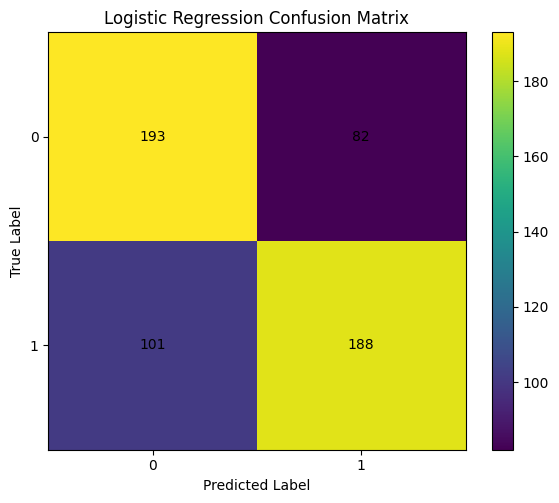

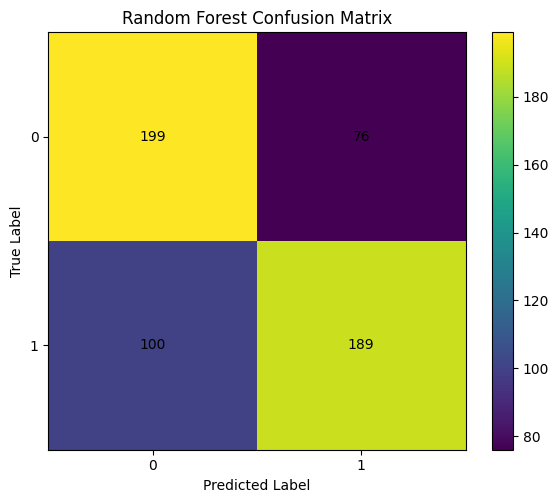

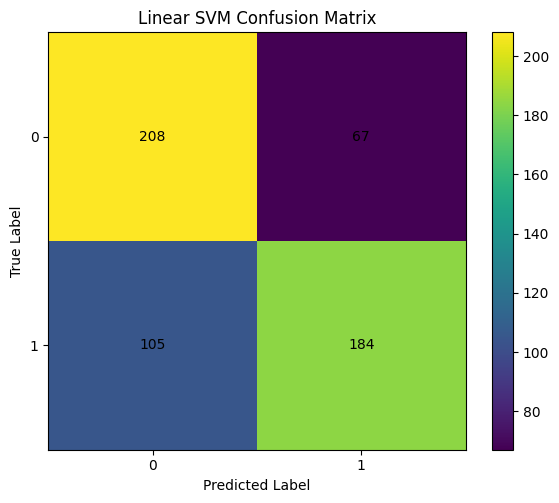

In [211]:
plot_confusion_matrix(
    lr_test_predictions,
    "Logistic Regression",
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/lr_confusion_matrix.png"
)

plot_confusion_matrix(
    rf_test_predictions,
    "Random Forest",
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/rf_confusion_matrix.png"
)

plot_confusion_matrix(
    svm_test_predictions,
    "Linear SVM",
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/svm_confusion_matrix.png"
)

### Task 4.4: Scalability Test

#### Batch Processing

In [213]:
def measure_time(task_name, function_to_run):
    start_time = time.time()
    function_to_run()
    end_time = time.time()

    duration = end_time - start_time

    print(f"{task_name} took {duration:.2f} seconds")

    return duration

In [224]:
input_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/small_dataset_parquet"
df = spark.read.parquet(input_path)

In [246]:
def run_batch_pipeline_benchmark(spark):
    input_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project/data/processed/stylometric_features_parquet"

    df = spark.read.parquet(input_path)

    df = df.select(
        "text",
        "label",
        "honore_r",
        "noun_frequency",
        "genitive_count",
        "entity_density"
    ).dropna()

    df = df.dropDuplicates(["text"])

    # Label indexing
    label_indexer = StringIndexer(
        inputCol="label",
        outputCol="label_index"
    )

    label_model = label_indexer.fit(df)
    df = label_model.transform(df)

    # Split
    train_df, val_df, test_df = df.randomSplit([0.70, 0.15, 0.15], seed=42)

    # Tokenization
    tokenizer = RegexTokenizer(
        inputCol="text",
        outputCol="tokens",
        pattern="\\s+",
        minTokenLength=2
    )

    train_df = tokenizer.transform(train_df)
    test_df = tokenizer.transform(test_df)

    # Stop-word removal
    arabic_stopwords = [
        "من", "في", "على", "عن", "الى", "إلى", "أن", "إن", "كان", "كانت",
        "هو", "هي", "هذا", "هذه", "ذلك", "تلك", "مع", "كما", "قد", "تم",
        "لا", "ما", "لم", "لن", "او", "أو", "أي", "كل", "بين", "بعد",
        "قبل", "عند", "اذا", "إذا", "هناك", "وقد", "حيث", "ثم", "به",
        "بها", "له", "لها", "ومن", "وفي", "وعلى", "والتي", "الذي",
        "التي", "الذين", "اللاتي", "ان", "او"
    ]

    remover = StopWordsRemover(
        inputCol="tokens",
        outputCol="filtered_tokens",
        stopWords=arabic_stopwords
    )

    train_df = remover.transform(train_df)
    test_df = remover.transform(test_df)

    # CountVectorizer
    count_vectorizer = CountVectorizer(
        inputCol="filtered_tokens",
        outputCol="raw_tf_features",
        vocabSize=1000,
        minDF=2
    )

    cv_model = count_vectorizer.fit(train_df)
    train_df = cv_model.transform(train_df)
    test_df = cv_model.transform(test_df)

    # IDF
    idf = IDF(
        inputCol="raw_tf_features",
        outputCol="tfidf_features"
    )

    idf_model = idf.fit(train_df)
    train_df = idf_model.transform(train_df)
    test_df = idf_model.transform(test_df)

    # Assemble features
    assembler = VectorAssembler(
        inputCols=[
            "honore_r",
            "noun_frequency",
            "genitive_count",
            "entity_density",
            "tfidf_features"
        ],
        outputCol="features"
    )

    train_df = assembler.transform(train_df)
    test_df = assembler.transform(test_df)

    train_df = train_df.cache()
    test_df = test_df.cache()

    train_df.count()
    test_df.count()

    # Train baseline model
    lr = LogisticRegression(
        featuresCol="features",
        labelCol="label_index",
        maxIter=5,
        regParam=0.1
    )

    lr_model = lr.fit(train_df)

    predictions = lr_model.transform(test_df)

    accuracy_evaluator = MulticlassClassificationEvaluator(
        labelCol="label_index",
        predictionCol="prediction",
        metricName="accuracy"
    )

# F1-score evaluator
    f1_evaluator = MulticlassClassificationEvaluator(
       labelCol="label_index",
        predictionCol="prediction",
        metricName="f1"
    )

# ROC-AUC evaluator
    auc_evaluator = BinaryClassificationEvaluator(
        labelCol="label_index",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    accuracy = accuracy_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)
    roc_auc = auc_evaluator.evaluate(predictions)

    return accuracy, f1, roc_auc

In [248]:
batch_results = []

resource_settings = [
    ("local[1]", 1),
    ("local[2]", 2),
    ("local[4]", 4)
]

for master_setting, cores in resource_settings:
    try:
        spark.stop()
    except:
        pass

    spark = SparkSession.builder \
        .appName(f"Batch Benchmark {master_setting}") \
        .master(master_setting) \
        .config("spark.driver.memory", "8g") \
        .config("spark.sql.shuffle.partitions", "4") \
        .getOrCreate()

    start_time = time.time()

    accuracy, f1, roc_auc = run_batch_pipeline_benchmark(spark)

    end_time = time.time()
    duration = end_time - start_time

    batch_results.append({
        "mode": master_setting,
        "cores": cores,
        "batch_time_seconds": duration,
        "accuracy": accuracy,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

    print(
        f"{master_setting} finished in {duration:.2f} seconds | "
        f"Accuracy={accuracy:.4f}, F1-score={f1:.4f}, ROC-AUC={roc_auc:.4f}"
    )

batch_results_df = pd.DataFrame(batch_results)

batch_results_df

local[1] finished in 2.67 seconds | Accuracy=0.9792, F1-score=0.9792, ROC-AUC=0.9966
local[2] finished in 2.21 seconds | Accuracy=0.9792, F1-score=0.9792, ROC-AUC=0.9964
local[4] finished in 1.89 seconds | Accuracy=0.9792, F1-score=0.9792, ROC-AUC=0.9964


,mode,cores,batch_time_seconds,accuracy,f1_score,roc_auc
0,local[1],1,2.671212,0.979167,0.979157,0.996647
1,local[2],2,2.205912,0.979167,0.979157,0.996381
2,local[4],4,1.886339,0.979167,0.979157,0.996381


In [249]:
batch_results_df.to_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/batch_scalability_results.csv",
    index=False
)

In [251]:
spark.conf.set("spark.sql.adaptive.enabled", "false")

#### Stream Processing

In [284]:
import os
import shutil

base_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project"
stream_batches_path = f"{base_path}/data/manual_stream_batches"

if os.path.exists(stream_batches_path):
    shutil.rmtree(stream_batches_path)

os.makedirs(stream_batches_path, exist_ok=True)

print("Old stream batches deleted.")

Old stream batches deleted.


In [285]:
base_path = "/Users/mo-alnajjar/ai_arabic_bigdata_project"

stylometric_path = f"{base_path}/data/processed/stylometric_features_parquet"

stylometric_df = spark.read.parquet(stylometric_path)

In [ ]:


stream_batches_path = f"{base_path}/data/manual_stream_batches"

if os.path.exists(stream_batches_path):
    shutil.rmtree(stream_batches_path)

os.makedirs(stream_batches_path, exist_ok=True)

stream_source_df = stylometric_df.select(
    "text",
    "label",
    "honore_r",
    "noun_frequency",
    "genitive_count",
    "entity_density"
).dropna()

stream_source_df.groupBy("label").count().show()

stream_pdf = stream_source_df.limit(100).toPandas()

batch_size = 10

for i in range(0, len(stream_pdf), batch_size):
    batch = stream_pdf.iloc[i:i + batch_size]
    batch_file = f"{stream_batches_path}/batch_{i//batch_size}.csv"
    batch.to_csv(batch_file, index=False, encoding="utf-8-sig")
    print("Created:", batch_file)

+------------+-----+
|       label|count|
+------------+-----+
|ai_generated| 2000|
|       human| 2000|
+------------+-----+

Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_0.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_1.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_2.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_3.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_4.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_5.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_6.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_7.csv
Created: /Users/mo-alnajjar/ai_arabic_bigdata_project/data/manual_stream_batches/batch_8.csv
Created: /Users/mo-alnajjar/ai_arabi

In [287]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType

stream_schema = StructType([
    StructField("text", StringType(), True),
    StructField("label", StringType(), True),
    StructField("honore_r", DoubleType(), True),
    StructField("noun_frequency", DoubleType(), True),
    StructField("genitive_count", IntegerType(), True),
    StructField("entity_density", DoubleType(), True)
])

In [ ]:
import time
import pandas as pd
from pyspark.sql.types import StructType, StructField, StringType
from pyspark.sql.functions import col, when
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizerModel, IDFModel, VectorAssembler
from pyspark.ml.classification import LogisticRegressionModel

cv_model = CountVectorizerModel.load(
    f"{base_path}/models/count_vectorizer_model"
)

idf_model = IDFModel.load(
    f"{base_path}/models/idf_model"
)

best_model = LogisticRegressionModel.load(
    f"{base_path}/models/baseline_logistic_regression_model"
)


In [289]:
arabic_stopwords = [
    "من", "في", "على", "عن", "الى", "إلى", "أن", "إن", "كان", "كانت",
    "هو", "هي", "هذا", "هذه", "ذلك", "تلك", "مع", "كما", "قد", "تم",
    "لا", "ما", "لم", "لن", "او", "أو", "أي", "كل", "بين", "بعد",
    "قبل", "عند", "اذا", "إذا", "هناك", "وقد", "حيث", "ثم", "به",
    "بها", "له", "لها", "ومن", "وفي", "وعلى", "والتي", "الذي",
    "التي", "الذين", "اللاتي", "ان", "او"
]

tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern="\\s+",
    minTokenLength=2
)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens",
    stopWords=arabic_stopwords
)


assembler = VectorAssembler(
    inputCols=[
        "honore_r",
        "noun_frequency",
        "genitive_count",
        "entity_density"
    ],
    outputCol="features"
)

stream_schema = StructType([
    StructField("text", StringType(), True),
    StructField("label", StringType(), True)
])

In [291]:
stream_schema = StructType([
    StructField("text", StringType(), True),
    StructField("label", StringType(), True),
    StructField("honore_r", DoubleType(), True),
    StructField("noun_frequency", DoubleType(), True),
    StructField("genitive_count", IntegerType(), True),
    StructField("entity_density", DoubleType(), True)
])

In [292]:
import time
import pandas as pd
from pyspark.sql.functions import col, when

stream_results = []

batch_files = sorted([
    f for f in os.listdir(stream_batches_path)
    if f.endswith(".csv")
])

for batch_file in batch_files:
    batch_path = os.path.join(stream_batches_path, batch_file)

    start_time = time.time()

    batch_df = spark.read.csv(
        batch_path,
        header=True,
        schema=stream_schema,
        multiLine=True,
        escape='"'
    )

    batch_count = batch_df.count()

    batch_df = batch_df.select(
        "text",
        "label",
        "honore_r",
        "noun_frequency",
        "genitive_count",
        "entity_density"
    ).dropna()

    if "features" in batch_df.columns:
        batch_df = batch_df.drop("features")

    batch_df = assembler.transform(batch_df)

    predictions = best_model.transform(batch_df)

    predictions = predictions.withColumn(
        "predicted_label",
        when(col("prediction") == 0.0, "ai_generated")
        .otherwise("human")
    )

    predictions.select(
        "text",
        "label",
        "predicted_label"
    ).show(5, truncate=80)

    end_time = time.time()

    latency = end_time - start_time
    throughput = batch_count / latency if latency > 0 else 0

    stream_results.append({
        "batch_file": batch_file,
        "num_records": batch_count,
        "latency_seconds": latency,
        "throughput_records_per_second": throughput
    })

    print(
        f"{batch_file}: latency={latency:.2f}s, "
        f"throughput={throughput:.2f} records/sec"
    )

stream_results_df = pd.DataFrame(stream_results)
stream_results_df

+--------------------------------------------------------------------------------+-----+---------------+
|                                                                            text|label|predicted_label|
+--------------------------------------------------------------------------------+-----+---------------+
|كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات ...|human|          human|
|يعد العامل الثقافي احد ابرز الاسباب التي يعزى لها سقوط الدولة الموحدية ، حتى ...|human|          human|
|شكلت تلك الجهود والمساعي الرائدة التي قام بها قادة الثورة خلال مرحلتها الأولى...|human|   ai_generated|
|يقوم المقال على اشكالية الضرائب الغير شرعية في مختلف مراحل دولتي المرابطين وا...|human|          human|
|تتفق المصادر التاريخية المتوفرة حول موضوع تطور الحركة الوطنية الجزائرية بعد ن...|human|          human|
+--------------------------------------------------------------------------------+-----+---------------+
only showing top 5 rows
batch_0.csv: latency=0.14s, thr

,batch_file,num_records,latency_seconds,throughput_records_per_second
0,batch_0.csv,10,0.140691,71.077731
1,batch_1.csv,10,0.110778,90.270555
2,batch_2.csv,10,0.081798,122.252263
3,batch_3.csv,10,0.081518,122.672391
4,batch_4.csv,10,0.086231,115.967905
5,batch_5.csv,10,0.103005,97.082730
6,batch_6.csv,10,0.114847,87.072408
7,batch_7.csv,10,0.079639,125.566310
8,batch_8.csv,10,0.072582,137.775194
9,batch_9.csv,10,0.079217,126.235599


In [293]:
stream_results_df.to_csv(
    f"{base_path}/reports/figures/stylometric_stream_benchmark_results.csv",
    index=False
)

NameError: name 'figures_path' is not defined

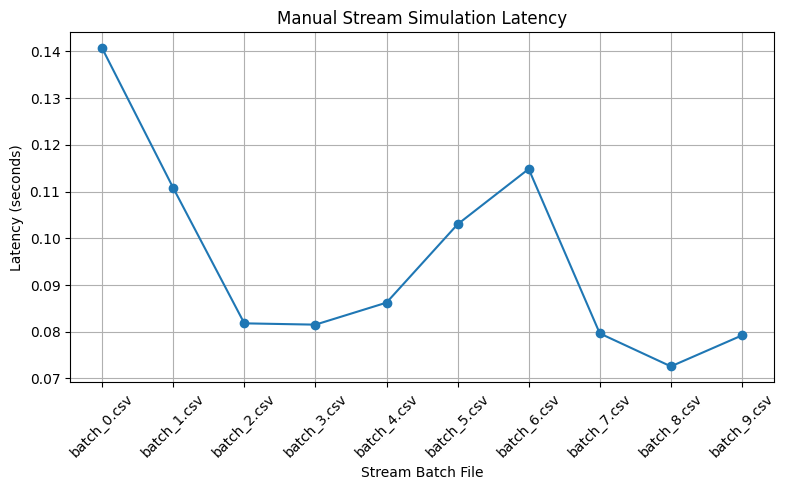

In [294]:
plt.figure(figsize=(8, 5))

plt.plot(
    stream_results_df["batch_file"],
    stream_results_df["latency_seconds"],
    marker="o"
)

plt.xlabel("Stream Batch File")
plt.ylabel("Latency (seconds)")
plt.title("Manual Stream Simulation Latency")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

latency_plot_path = f"{figures_path}/stream_latency_plot.png"
plt.savefig(latency_plot_path, dpi=300)

plt.show()

print("Saved plot to:", latency_plot_path)

NameError: name 'figures_path' is not defined

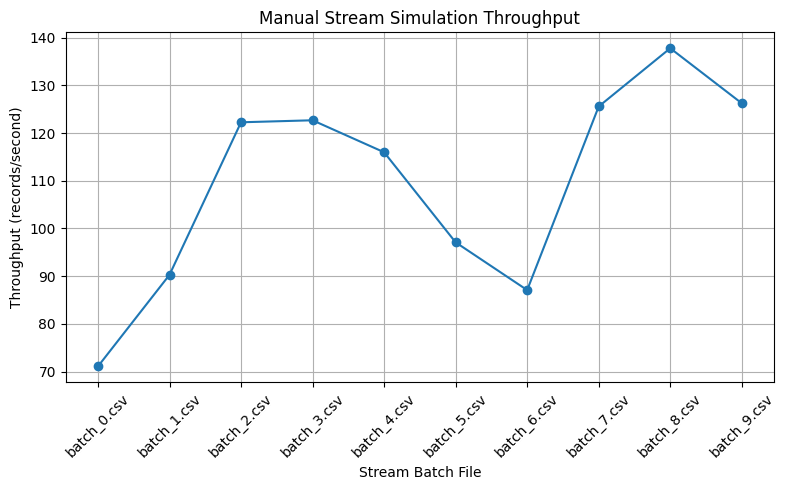

In [295]:
plt.figure(figsize=(8, 5))

plt.plot(
    stream_results_df["batch_file"],
    stream_results_df["throughput_records_per_second"],
    marker="o"
)

plt.xlabel("Stream Batch File")
plt.ylabel("Throughput (records/second)")
plt.title("Manual Stream Simulation Throughput")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

throughput_plot_path = f"{figures_path}/stream_throughput_plot.png"
plt.savefig(throughput_plot_path, dpi=300)

plt.show()

print("Saved plot to:", throughput_plot_path)

## Phase 5: Analysis, Interpretation & Final Reporting

### Task 5.1: Compare the performance of all models and the trade-offs between batch and stream processing.

In [296]:
import pandas as pd

model_comparison_df = pd.DataFrame([
    lr_results,
    rf_results,
    svm_results
])

model_comparison_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.675532,0.676874,0.675532,0.675435,0.756011
1,Random Forest,0.687943,0.689971,0.687943,0.687708,0.753797
2,Linear SVM,0.695035,0.699653,0.695035,0.694160,0.758402


In [297]:
model_comparison_df.to_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/model_comparison_results.csv",
    index=False
)

In [298]:
best_model_row = model_comparison_df.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

best_model_row

model        Linear SVM
accuracy       0.695035
precision      0.699653
recall         0.695035
f1_score        0.69416
roc_auc        0.758402
Name: 2, dtype: object

In [299]:
print("Best model:", best_model_row["model"])
print("Best F1-score:", best_model_row["f1_score"])

Best model: Linear SVM
Best F1-score: 0.694159523541489


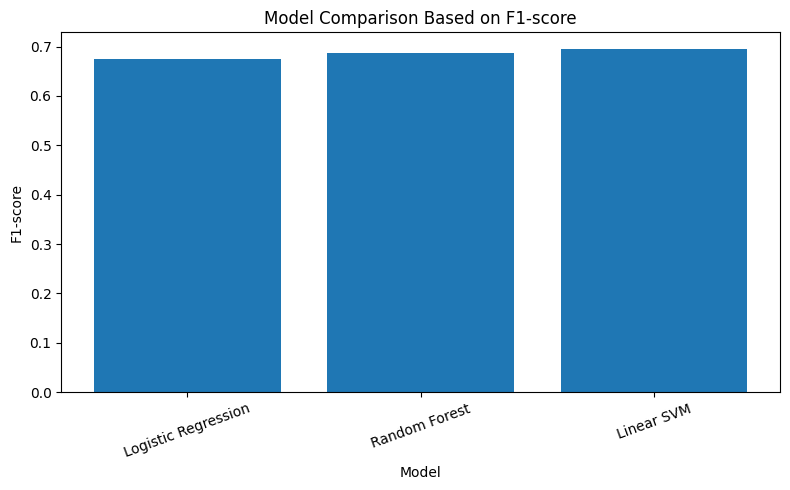

In [300]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison_df["model"],
    model_comparison_df["f1_score"]
)

plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("Model Comparison Based on F1-score")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/model_f1_comparison.png",
    dpi=300
)

plt.show()

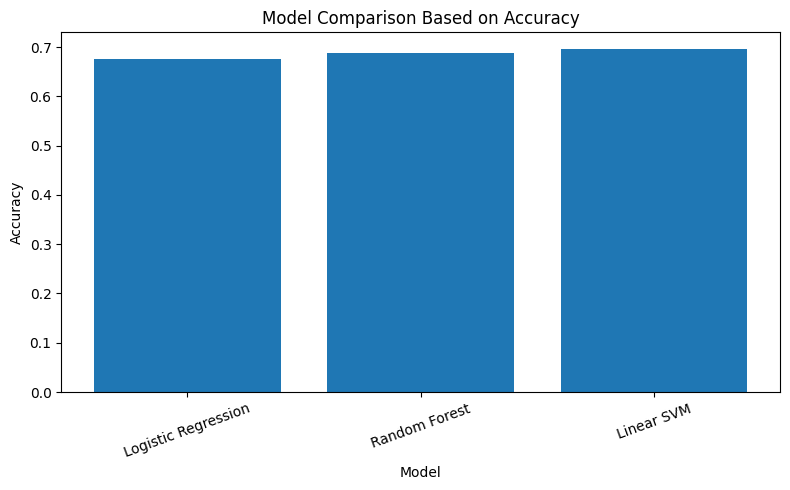

In [301]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison_df["model"],
    model_comparison_df["accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison Based on Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/model_accuracy_comparison.png",
    dpi=300
)

plt.show()

In [302]:
batch_scalability_df = pd.read_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/batch_scalability_results.csv"
)

batch_scalability_df

,mode,cores,batch_time_seconds,accuracy,f1_score,roc_auc
0,local[1],1,2.671212,0.979167,0.979157,0.996647
1,local[2],2,2.205912,0.979167,0.979157,0.996381
2,local[4],4,1.886339,0.979167,0.979157,0.996381


In [303]:
stream_benchmark_df = pd.read_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/stylometric_stream_benchmark_results.csv"
)

stream_benchmark_df

,batch_file,num_records,latency_seconds,throughput_records_per_second
0,batch_0.csv,10,0.140691,71.077731
1,batch_1.csv,10,0.110778,90.270555
2,batch_2.csv,10,0.081798,122.252263
3,batch_3.csv,10,0.081518,122.672391
4,batch_4.csv,10,0.086231,115.967905
5,batch_5.csv,10,0.103005,97.082730
6,batch_6.csv,10,0.114847,87.072408
7,batch_7.csv,10,0.079639,125.566310
8,batch_8.csv,10,0.072582,137.775194
9,batch_9.csv,10,0.079217,126.235599


In [304]:
stream_summary = {
    "average_latency_seconds": stream_benchmark_df["latency_seconds"].mean(),
    "average_throughput_records_per_second": stream_benchmark_df["throughput_records_per_second"].mean(),
    "minimum_latency_seconds": stream_benchmark_df["latency_seconds"].min(),
    "maximum_latency_seconds": stream_benchmark_df["latency_seconds"].max()
}

stream_summary

{'average_latency_seconds': np.float64(0.09503059387207027),
 'average_throughput_records_per_second': np.float64(109.59730851927691),
 'minimum_latency_seconds': np.float64(0.0725820064544677),
 'maximum_latency_seconds': np.float64(0.1406910419464111)}

In [305]:
stream_summary_df = pd.DataFrame([stream_summary])

stream_summary_df

,average_latency_seconds,average_throughput_records_per_second,minimum_latency_seconds,maximum_latency_seconds
0,0.095031,109.597309,0.072582,0.140691


In [306]:
stream_summary_df.to_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/stream_summary_results.csv",
    index=False
)

### Task 5.2: For the best-performing traditional model, extract and visualize feature importances/coefficients.

In [307]:
feature_names = [
    "honore_r",
    "noun_frequency",
    "genitive_count",
    "entity_density"
]

In [310]:
svm_coefficients = svm_model.coefficients.toArray()

svm_coefficients_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": svm_coefficients
})

svm_coefficients_df["absolute_coefficient"] = svm_coefficients_df["coefficient"].abs()

svm_coefficients_df = svm_coefficients_df.sort_values(
    by="absolute_coefficient",
    ascending=False
)

svm_coefficients_df

,feature,coefficient,absolute_coefficient
1,noun_frequency,-15.730219,15.730219
3,entity_density,-12.921685,12.921685
2,genitive_count,0.044878,0.044878
0,honore_r,0.000215,0.000215


In [311]:
svm_coefficients_df.to_csv(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/linear_svm_feature_coefficients.csv",
    index=False
)

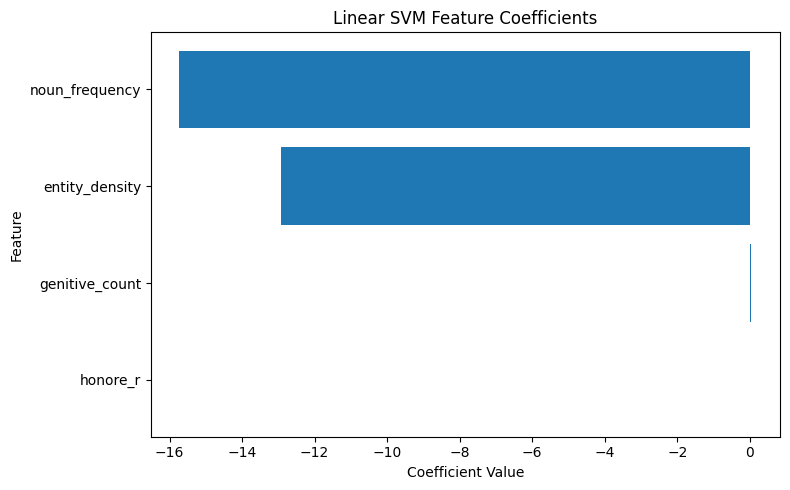

In [312]:
plt.figure(figsize=(8, 5))

plt.barh(
    svm_coefficients_df["feature"],
    svm_coefficients_df["coefficient"]
)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear SVM Feature Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "/Users/mo-alnajjar/ai_arabic_bigdata_project/reports/figures/linear_svm_feature_coefficients.png",
    dpi=300
)

plt.show()